<a href="https://colab.research.google.com/github/iate8/Skyler-Fronczke-CIS-115/blob/main/week15Assignment2/week15Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import json
from datetime import datetime

class WaterReading:
    """Represents a single water parameter reading."""
    def __init__(self, ammonia, nitrite, nitrate, ph, temperature, timestamp=None):
        self.ammonia = ammonia
        self.nitrite = nitrite
        self.nitrate = nitrate
        self.ph = ph
        self.temperature = temperature
        self.timestamp = timestamp if timestamp else datetime.now().isoformat()

    def to_dict(self):
        """Converts the WaterReading object to a dictionary for JSON serialization."""
        return {
            'ammonia': self.ammonia,
            'nitrite': self.nitrite,
            'nitrate': self.nitrate,
            'ph': self.ph,
            'temperature': self.temperature,
            'timestamp': self.timestamp
        }

    @classmethod
    def from_dict(cls, data):
        """Creates a WaterReading object from a dictionary."""
        return cls(
            data['ammonia'],
            data['nitrite'],
            data['nitrate'],
            data['ph'],
            data['temperature'],
            data['timestamp']
        )

    def __str__(self):
        return (f"Timestamp: {self.timestamp}, Ammonia: {self.ammonia}, Nitrite: {self.nitrite}, "
                f"Nitrate: {self.nitrate}, pH: {self.ph}, Temp: {self.temperature}°C")


In [27]:
class WaterLogManager:
    """Manages a collection of water readings, including persistence."""
    def __init__(self, filename='water_readings.json'):
        self.filename = filename
        self.readings = []
        self._load_readings()

    def _load_readings(self):
        """Loads water readings from the JSON file."""
        try:
            with open(self.filename, 'r') as f:
                data = json.load(f)
                self.readings = [WaterReading.from_dict(item) for item in data]
        except FileNotFoundError:
            self.readings = []
        except json.JSONDecodeError:
            print(f"Warning: Could not decode JSON from {self.filename}. Starting with empty log.")
            self.readings = []

    def _save_readings(self):
        """Saves all current water readings to the JSON file."""
        with open(self.filename, 'w') as f:
            json.dump([r.to_dict() for r in self.readings], f, indent=4)

    def add_reading(self, ammonia, nitrite, nitrate, ph, temperature):
        """Adds a new water reading to the log and saves it."""
        new_reading = WaterReading(ammonia, nitrite, nitrate, ph, temperature)
        self.readings.append(new_reading)
        self._save_readings()
        print(f"Reading added: {new_reading}")

    def get_all_readings(self):
        """Returns a list of all logged water readings."""
        return self.readings

    def display_readings(self):
        """Prints all logged water readings."""
        if not self.readings:
            print("No water readings logged yet.")
            return
        print("--- Water Readings Log ---")
        for reading in self.readings:
            print(reading)
        print("--------------------------")

    def analyze_reading(self, reading):
        """Analyzes a single water reading against safe ranges and prints alerts."""
        print(f"\n--- Analysis for Reading: {reading.timestamp} ---")
        alerts = []

        # Define safe ranges (these can be made configurable later)
        safe_ranges = {
            'ammonia': (0.0, 0.0), # Ideally 0
            'nitrite': (0.0, 0.0), # Ideally 0
            'nitrate': (0.0, 40.0), # Up to 40ppm is generally okay for planted tanks, lower for others
            'ph': (6.5, 7.5), # Varies by fish, common freshwater range
            'temperature': (23.0, 27.0) # Varies by fish, common tropical range in Celsius
        }

        if not (safe_ranges['ammonia'][0] <= reading.ammonia <= safe_ranges['ammonia'][1]):
            alerts.append(f"CRITICAL: Ammonia ({reading.ammonia} ppm) is outside safe range ({safe_ranges['ammonia'][0]}-{safe_ranges['ammonia'][1]} ppm).")
        if not (safe_ranges['nitrite'][0] <= reading.nitrite <= safe_ranges['nitrite'][1]):
            alerts.append(f"CRITICAL: Nitrite ({reading.nitrite} ppm) is outside safe range ({safe_ranges['nitrite'][0]}-{safe_ranges['nitrite'][1]} ppm).")
        if not (safe_ranges['nitrate'][0] <= reading.nitrate <= safe_ranges['nitrate'][1]):
            alerts.append(f"WARNING: Nitrate ({reading.nitrate} ppm) is outside safe range ({safe_ranges['nitrate'][0]}-{safe_ranges['nitrate'][1]} ppm).")
        if not (safe_ranges['ph'][0] <= reading.ph <= safe_ranges['ph'][1]):
            alerts.append(f"WARNING: pH ({reading.ph}) is outside safe range ({safe_ranges['ph'][0]}-{safe_ranges['ph'][1]}).")
        if not (safe_ranges['temperature'][0] <= reading.temperature <= safe_ranges['temperature'][1]):
            alerts.append(f"WARNING: Temperature ({reading.temperature}°C) is outside safe range ({safe_ranges['temperature'][0]}-{safe_ranges['temperature'][1]}°C).")

        if alerts:
            for alert in alerts:
                print(alert)
        else:
            print("All parameters are within safe ranges. Good job!")
        print("-------------------------------------")

In [28]:
# Initialize the manager
water_manager = WaterLogManager()

# Add some sample readings
print("Adding sample readings...")
water_manager.add_reading(ammonia=0.0, nitrite=0.0, nitrate=5.0, ph=7.2, temperature=25.5)
water_manager.add_reading(ammonia=0.25, nitrite=0.0, nitrate=10.0, ph=7.0, temperature=25.0)
water_manager.add_reading(ammonia=0.0, nitrite=0.0, nitrate=20.0, ph=6.8, temperature=24.8)

# Display all logged readings
water_manager.display_readings()

print("\n--- To add more readings, simply call water_manager.add_reading() with new values ---")


Adding sample readings...
Reading added: Timestamp: 2026-04-25T02:37:30.859284, Ammonia: 0.0, Nitrite: 0.0, Nitrate: 5.0, pH: 7.2, Temp: 25.5°C
Reading added: Timestamp: 2026-04-25T02:37:30.860148, Ammonia: 0.25, Nitrite: 0.0, Nitrate: 10.0, pH: 7.0, Temp: 25.0°C
Reading added: Timestamp: 2026-04-25T02:37:30.860612, Ammonia: 0.0, Nitrite: 0.0, Nitrate: 20.0, pH: 6.8, Temp: 24.8°C
--- Water Readings Log ---
Timestamp: 2026-04-25T02:33:53.952875, Ammonia: 0.0, Nitrite: 0.0, Nitrate: 5.0, pH: 7.2, Temp: 25.5°C
Timestamp: 2026-04-25T02:33:53.953615, Ammonia: 0.25, Nitrite: 0.0, Nitrate: 10.0, pH: 7.0, Temp: 25.0°C
Timestamp: 2026-04-25T02:33:53.953970, Ammonia: 0.0, Nitrite: 0.0, Nitrate: 20.0, pH: 6.8, Temp: 24.8°C
Timestamp: 2026-04-25T02:37:30.859284, Ammonia: 0.0, Nitrite: 0.0, Nitrate: 5.0, pH: 7.2, Temp: 25.5°C
Timestamp: 2026-04-25T02:37:30.860148, Ammonia: 0.25, Nitrite: 0.0, Nitrate: 10.0, pH: 7.0, Temp: 25.0°C
Timestamp: 2026-04-25T02:37:30.860612, Ammonia: 0.0, Nitrite: 0.0, Nit

In [29]:
# Analyze all existing readings
print("\n--- Analyzing Existing Readings ---")
for reading in water_manager.get_all_readings():
    water_manager.analyze_reading(reading)

# Add a new reading with some parameters outside the safe ranges
print("\nAdding a new reading with potential issues...")
water_manager.add_reading(ammonia=0.5, nitrite=0.2, nitrate=60.0, ph=8.0, temperature=28.5)

# Analyze the newly added reading
print("\n--- Analyzing Latest Reading ---")
latest_reading = water_manager.get_all_readings()[-1]
water_manager.analyze_reading(latest_reading)

print("\n--- All readings analyzed ---")


--- Analyzing Existing Readings ---

--- Analysis for Reading: 2026-04-25T02:33:53.952875 ---
All parameters are within safe ranges. Good job!
-------------------------------------

--- Analysis for Reading: 2026-04-25T02:33:53.953615 ---
CRITICAL: Ammonia (0.25 ppm) is outside safe range (0.0-0.0 ppm).
-------------------------------------

--- Analysis for Reading: 2026-04-25T02:33:53.953970 ---
All parameters are within safe ranges. Good job!
-------------------------------------

--- Analysis for Reading: 2026-04-25T02:37:30.859284 ---
All parameters are within safe ranges. Good job!
-------------------------------------

--- Analysis for Reading: 2026-04-25T02:37:30.860148 ---
CRITICAL: Ammonia (0.25 ppm) is outside safe range (0.0-0.0 ppm).
-------------------------------------

--- Analysis for Reading: 2026-04-25T02:37:30.860612 ---
All parameters are within safe ranges. Good job!
-------------------------------------

Adding a new reading with potential issues...
Reading adde

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get all readings from the manager
all_readings = water_manager.get_all_readings()

# Convert readings to a list of dictionaries
readings_data = [reading.to_dict() for reading in all_readings]

# Create a Pandas DataFrame
df_readings = pd.DataFrame(readings_data)

# Convert timestamp to datetime objects
df_readings['timestamp'] = pd.to_datetime(df_readings['timestamp'])

# Sort by timestamp to ensure correct plotting order
df_readings = df_readings.sort_values(by='timestamp').reset_index(drop=True)

display(df_readings.head())


,ammonia,nitrite,nitrate,ph,temperature,timestamp
0,0.00,0.0,5.0,7.2,25.5,2026-04-25 02:33:53.952875
1,0.25,0.0,10.0,7.0,25.0,2026-04-25 02:33:53.953615
2,0.00,0.0,20.0,6.8,24.8,2026-04-25 02:33:53.953970
3,0.00,0.0,5.0,7.2,25.5,2026-04-25 02:37:30.859284
4,0.25,0.0,10.0,7.0,25.0,2026-04-25 02:37:30.860148


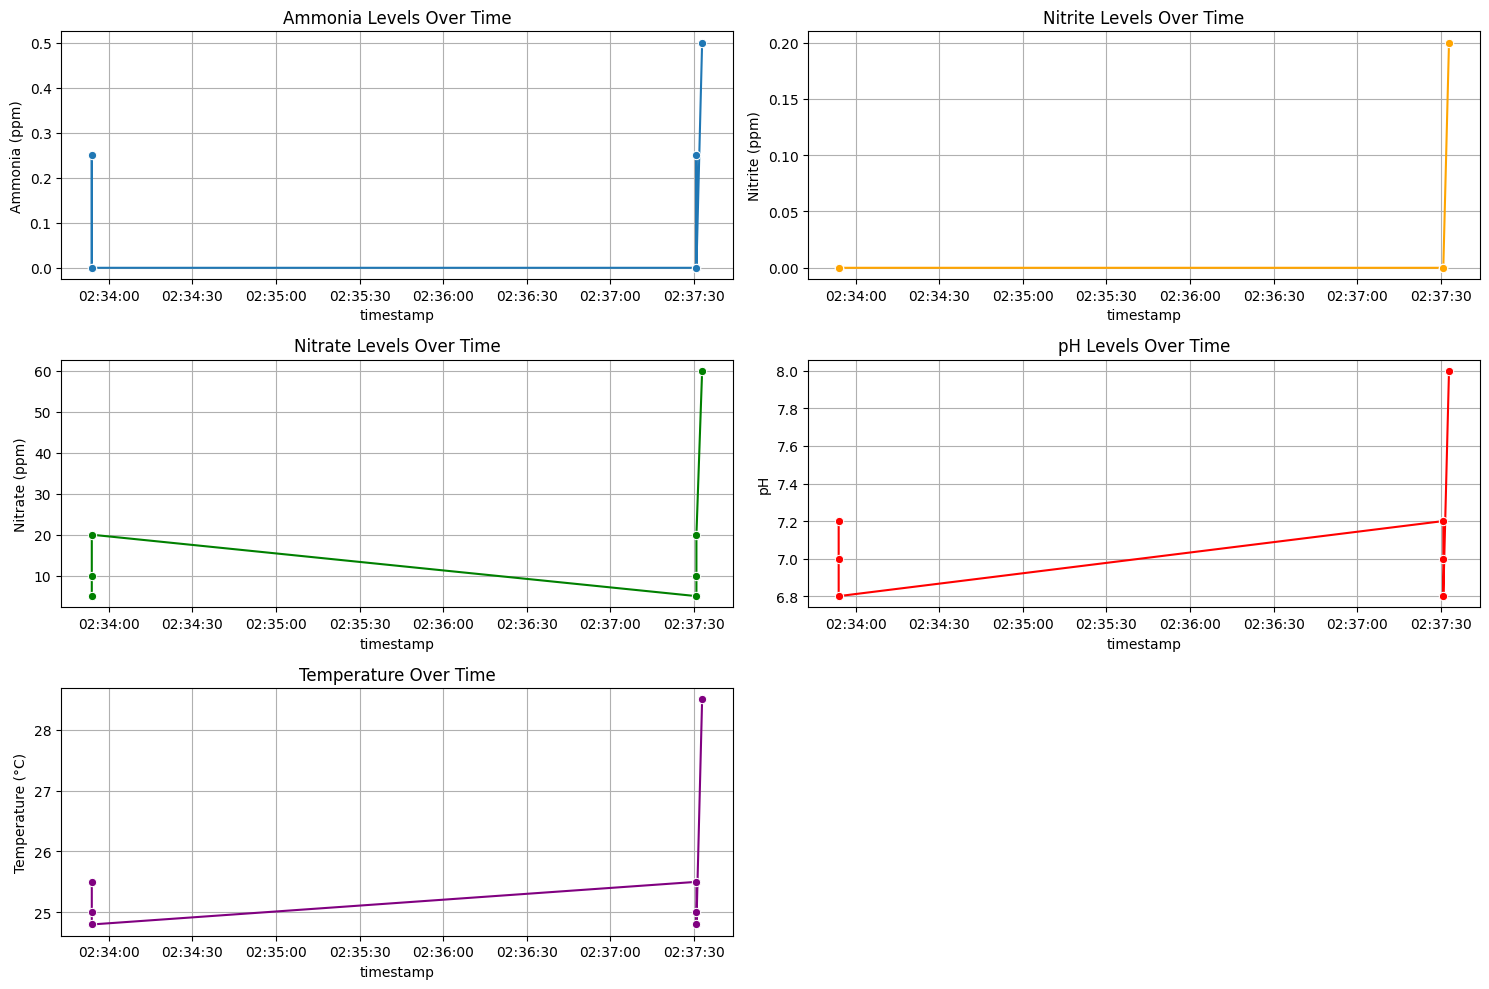

In [31]:
plt.figure(figsize=(15, 10))

# Plot Ammonia
plt.subplot(3, 2, 1)
sns.lineplot(x='timestamp', y='ammonia', data=df_readings, marker='o')
plt.title('Ammonia Levels Over Time')
plt.ylabel('Ammonia (ppm)')
plt.grid(True)

# Plot Nitrite
plt.subplot(3, 2, 2)
sns.lineplot(x='timestamp', y='nitrite', data=df_readings, marker='o', color='orange')
plt.title('Nitrite Levels Over Time')
plt.ylabel('Nitrite (ppm)')
plt.grid(True)

# Plot Nitrate
plt.subplot(3, 2, 3)
sns.lineplot(x='timestamp', y='nitrate', data=df_readings, marker='o', color='green')
plt.title('Nitrate Levels Over Time')
plt.ylabel('Nitrate (ppm)')
plt.grid(True)

# Plot pH
plt.subplot(3, 2, 4)
sns.lineplot(x='timestamp', y='ph', data=df_readings, marker='o', color='red')
plt.title('pH Levels Over Time')
plt.ylabel('pH')
plt.grid(True)

# Plot Temperature
plt.subplot(3, 2, 5)
sns.lineplot(x='timestamp', y='temperature', data=df_readings, marker='o', color='purple')
plt.title('Temperature Over Time')
plt.ylabel('Temperature (°C)')
plt.grid(True)

plt.tight_layout()
plt.show()


In [34]:
try:
    ammonia = float(input("Enter Ammonia level (ppm): "))
    nitrite = float(input("Enter Nitrite level (ppm): "))
    nitrate = float(input("Enter Nitrate level (ppm): "))
    ph = float(input("Enter pH level: "))
    temperature = float(input("Enter Temperature (°C): "))

    water_manager.add_reading(ammonia=ammonia, nitrite=nitrite, nitrate=nitrate, ph=ph, temperature=temperature)
    print("New reading added successfully!")
    # Optionally display all readings again after adding a new one
    water_manager.display_readings()
    # And analyze the new reading
    latest_reading = water_manager.get_all_readings()[-1]
    water_manager.analyze_reading(latest_reading)

except ValueError:
    print("Invalid input. Please enter numeric values for all parameters.")
except Exception as e:
    print(f"An error occurred: {e}")

Enter Ammonia level (ppm): 2
Enter Nitrite level (ppm): 3.3333
Enter Nitrate level (ppm): 0
Enter pH level: 7
Enter Temperature (°C): 28
Reading added: Timestamp: 2026-04-25T02:42:17.311042, Ammonia: 2.0, Nitrite: 3.3333, Nitrate: 0.0, pH: 7.0, Temp: 28.0°C
New reading added successfully!
--- Water Readings Log ---
Timestamp: 2026-04-25T02:33:53.952875, Ammonia: 0.0, Nitrite: 0.0, Nitrate: 5.0, pH: 7.2, Temp: 25.5°C
Timestamp: 2026-04-25T02:33:53.953615, Ammonia: 0.25, Nitrite: 0.0, Nitrate: 10.0, pH: 7.0, Temp: 25.0°C
Timestamp: 2026-04-25T02:33:53.953970, Ammonia: 0.0, Nitrite: 0.0, Nitrate: 20.0, pH: 6.8, Temp: 24.8°C
Timestamp: 2026-04-25T02:37:30.859284, Ammonia: 0.0, Nitrite: 0.0, Nitrate: 5.0, pH: 7.2, Temp: 25.5°C
Timestamp: 2026-04-25T02:37:30.860148, Ammonia: 0.25, Nitrite: 0.0, Nitrate: 10.0, pH: 7.0, Temp: 25.0°C
Timestamp: 2026-04-25T02:37:30.860612, Ammonia: 0.0, Nitrite: 0.0, Nitrate: 20.0, pH: 6.8, Temp: 24.8°C
Timestamp: 2026-04-25T02:37:32.905535, Ammonia: 0.5, Nitrit